# Poisson Distribution

The **Poisson distribution** counts the number of events occurring in a fixed interval of time or space, when events happen independently at a constant average rate λ. It has one unique property: **mean = variance = λ** — so overdispersion (variance > mean) in count data is a signal that Poisson doesn't fit.

| Property | Value |
|---|---|
| **Parameter** | λ (rate, λ > 0) |
| **Support** | {0, 1, 2, 3, …} |
| **PMF** | P(X=k) = e^(−λ) · λ^k / k! |
| **Mean** | λ |
| **Variance** | λ |
| **Std Dev** | √λ |
| **Skewness** | 1/√λ (right-skewed; decreases as λ↑) |
| **Estimation** | λ̂ = x̄ (MLE = sample mean) |
| **Normal approx** | Valid when λ ≥ 10 |
| **Binomial limit** | Binomial(n,p) → Poisson(λ=np) as n→∞, p→0 |

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

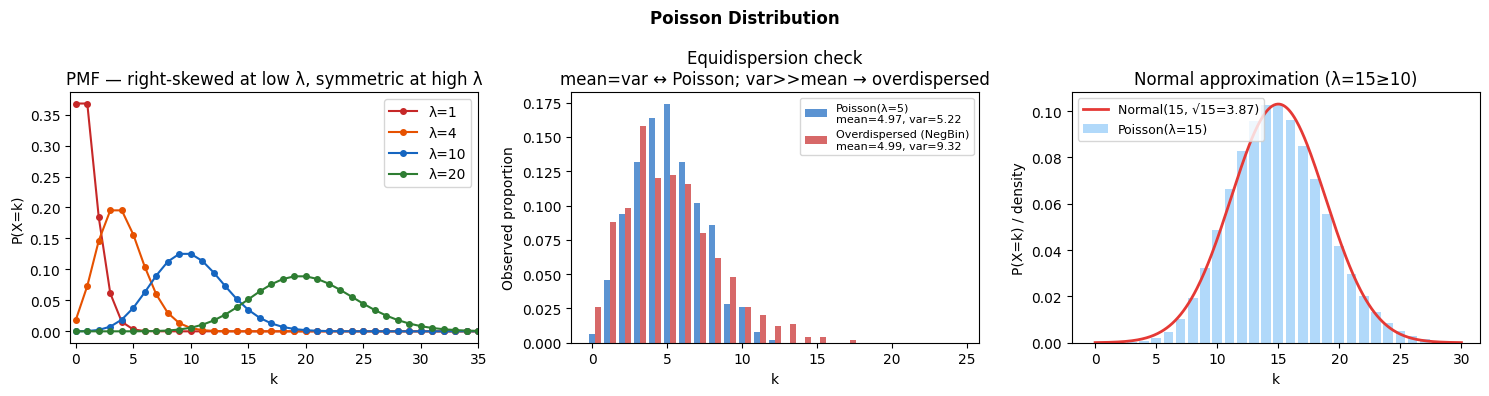

Poisson test: observed=7, expected rate=5.0
P(X ≥ 7 | λ=5.0) = 0.2378


In [2]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Poisson Distribution', fontsize=12, fontweight='bold')

# PMF — varying λ
for lam, color, label in [(1,  '#C62828', 'λ=1'),
                            (4,  '#E65100', 'λ=4'),
                            (10, '#1565C0', 'λ=10'),
                            (20, '#2E7D32', 'λ=20')]:
    k = np.arange(0, 40)
    pmf = stats.poisson(lam).pmf(k)
    axes[0].plot(k, pmf, 'o-', color=color, linewidth=1.5, markersize=4, label=f'λ={lam}')
axes[0].set_title('PMF — right-skewed at low λ, symmetric at high λ')
axes[0].set_xlabel('k'); axes[0].set_ylabel('P(X=k)')
axes[0].set_xlim(-0.5, 35)
axes[0].legend()

# Mean = Variance check (overdispersion test)
np.random.seed(42)
# Poisson data: mean ≈ variance
lam_true = 5
poisson_data = stats.poisson(lam_true).rvs(500)
# Overdispersed: Negative Binomial
nb_data = stats.nbinom(n=5, p=0.5).rvs(500)

datasets = [('Poisson(λ=5)', poisson_data, '#1565C0'),
            ('Overdispersed (NegBin)', nb_data, '#C62828')]
x_vals = np.arange(0, 25)
for label, data, color in datasets:
    pmf_obs = np.array([(data == k).mean() for k in x_vals])
    axes[1].bar(x_vals + (0 if color == '#1565C0' else 0.4), pmf_obs,
                width=0.4, color=color, alpha=0.7, label=f'{label}\nmean={data.mean():.2f}, var={data.var():.2f}')
axes[1].set_title('Equidispersion check\nmean=var ↔ Poisson; var>>mean → overdispersed')
axes[1].set_xlabel('k'); axes[1].set_ylabel('Observed proportion')
axes[1].legend(fontsize=8)

# Normal approximation at large λ
lam = 15
k_all = np.arange(0, 30)
pmf_exact = stats.poisson(lam).pmf(k_all)
x_cont = np.linspace(0, 30, 400)
normal_approx = stats.norm(lam, np.sqrt(lam)).pdf(x_cont)

axes[2].bar(k_all, pmf_exact, color='#90CAF9', alpha=0.7, label=f'Poisson(λ={lam})')
axes[2].plot(x_cont, normal_approx, color='#E53935', linewidth=2,
             label=f'Normal({lam}, √{lam}={np.sqrt(lam):.2f})')
axes[2].set_title(f'Normal approximation (λ={lam}≥10)')
axes[2].set_xlabel('k'); axes[2].set_ylabel('P(X=k) / density')
axes[2].legend(fontsize=9)

plt.tight_layout()
plt.show()

# Poisson test
observed_count = 7
expected_rate  = 5.0
p_val = 1 - stats.poisson(expected_rate).cdf(observed_count - 1)
print(f"Poisson test: observed={observed_count}, expected rate={expected_rate}")
print(f"P(X ≥ {observed_count} | λ={expected_rate}) = {p_val:.4f}")

## Key Takeaways

| | |
|---|---|
| **Mean = Variance** | The defining equidispersion property — test this on your data first |
| **Overdispersion** | var >> mean → use Negative Binomial instead |
| **Underdispersion** | var << mean → consider Conway-Maxwell-Poisson |
| **Estimation** | λ̂ = x̄ (sample mean is the MLE) |
| **Normal approx** | Use when λ ≥ 10 |
| **Additive** | Sum of k independent Poisson(λᵢ) ~ Poisson(Σλᵢ) |
| **Use cases** | Call centre arrivals, website clicks per minute, defects per unit area, rare disease counts |
| **Exponential link** | Inter-arrival times of Poisson(λ) process ~ Exponential(1/λ) |